``AAPredPlot().group_cluster(data, kind=...)`` is the **sample-relation** counterpart of ``predict_group``: it takes the sample x feature matrix ``data`` (feature values from ``SequenceFeature.feature_matrix``, or SHAP values from a fitted ``ShapModel``) and clusters the samples by how they relate &mdash; a hierarchically clustered sample x sample correlation heatmap.

Each sample can carry **two class annotations**: ``labels`` colors the top (column) sidebar and ``labels_row`` the left (row) sidebar, each with its own ``dict_color`` map and titled legend. A lone ``labels`` is mirrored onto both sides (the matrix is symmetric). The signature mirrors ``predict_group`` (``data``, ``labels``, ``dict_color``, ``names``, ``cmap``, ...).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import aaanalysis as aa
aa.options["verbose"] = False
aa.plot_settings(font_scale=0.8, weight_bold=False)
aap_plot = aa.AAPredPlot()

# Synthetic per-sample importance matrix: three blocks of samples with distinct signals.
rng = np.random.RandomState(1)
X = np.vstack([rng.normal(0.7, 0.25, size=(12, 30)),
               rng.normal(-0.2, 0.25, size=(8, 30)),
               rng.normal(-0.7, 0.25, size=(10, 30))])
names = [f"P{i:02d}" for i in range(30)]
# Two per-sample annotations: a prediction group (top) and a confidence band (left).
group = ["Substrate"] * 12 + ["Non-substrate (known)"] * 8 + ["Non-substrate (dPULearn)"] * 10
score = np.clip(np.concatenate([rng.normal(85, 12, 12), rng.normal(30, 18, 8),
                                rng.normal(15, 12, 10)]), 0, 100)
confidence = ["HC Substrate" if s >= 80 else "LC Substrate" if s >= 50
              else "LC Non-substrate" if s >= 20 else "HC Non-substrate" for s in score]

**Two annotations.** ``labels`` (prediction group) colors the top sidebar and ``labels_row`` (confidence band) the left sidebar; ``dict_color`` / ``dict_color_row`` fix each ``label -> color`` map (and the legend order), and ``legend_title`` / ``legend_title_row`` title the two legends. ``names`` sets the per-sample tick labels:

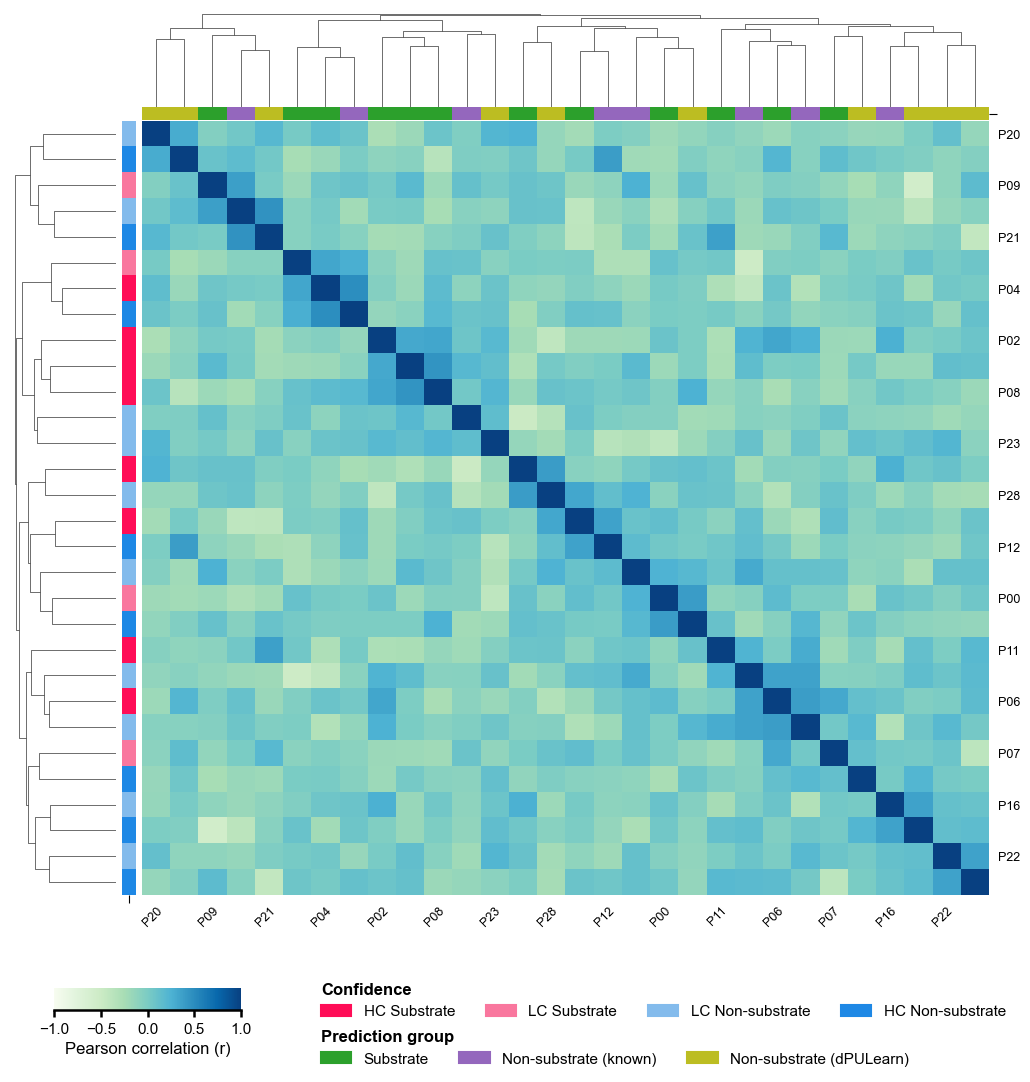

In [2]:
C_SUB, C_KNOWN, C_DPU = "tab:green", "tab:purple", "tab:olive"
dict_group = {"Substrate": C_SUB, "Non-substrate (known)": C_KNOWN, "Non-substrate (dPULearn)": C_DPU}
dict_conf = {"HC Substrate": "#FF0D57", "LC Substrate": "#F9779E",
             "LC Non-substrate": "#83BBEC", "HC Non-substrate": "#1E88E5"}
aap_plot.group_cluster(X, kind="clustermap",
                          labels=group, dict_color=dict_group, legend_title="Prediction group",
                          labels_row=confidence, dict_color_row=dict_conf, legend_title_row="Confidence",
                          names=names)
plt.show()

**Single annotation and further parameters.** With only ``labels`` the annotation is mirrored onto both sidebars. Here we also adjust the heatmap ``cmap``, the colorbar label (``cbar_label``), the ``figsize`` and a ``title``:

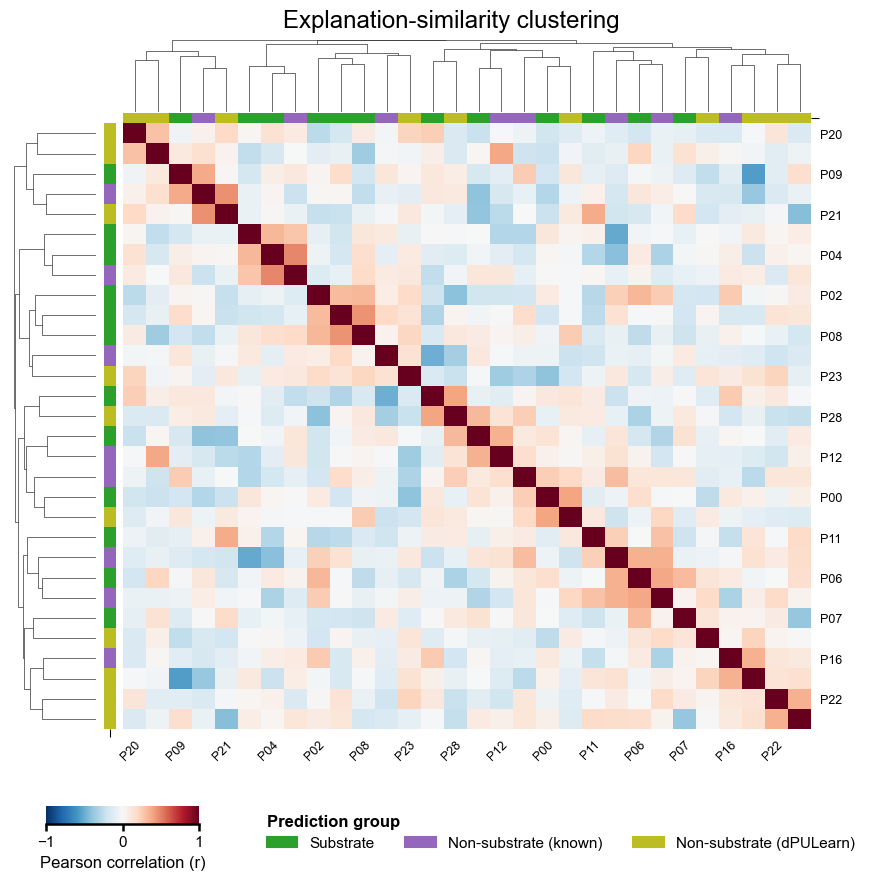

In [3]:
aap_plot.group_cluster(X, kind="clustermap", labels=group, dict_color=dict_group,
                          legend_title="Prediction group", names=names,
                          cmap="RdBu_r", cbar_label="Pearson correlation (r)", figsize=(9, 9),
                          title="Explanation-similarity clustering")
plt.show()